<a href="https://colab.research.google.com/github/mobarakol/tutorial_notebooks/blob/main/Lab_Week6_PathVQA_GPT_LoRA_Uncertainty_AFD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#IIDS67692 Computational Techniques for Multi-modal Data
#Lab: Multimodal Large Language Model

In this lab, we will be exploring different fusion techniques in a Multimodal Large Language Model for Health Decision Support

In [1]:
!nvidia-smi

Thu Jun  4 15:52:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   76C    P0             44W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

###Installing required python packages

In [2]:
!pip install -q datasets evaluate bert_score rouge_score torch torchvision transformers peft gdown --upgrade pip --upgrade torchao

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 123.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.8 MB/s eta 0:00:00
   ━━━━

#Dataset

Huggingface Link: https://huggingface.co/datasets/flaviagiammarino/path-vqa

The PathVQA Dataset is available on Hugging Face and contains 19,654 training, 6,259 validation, and 6,719 test question-answer pairs across approximately 5,004 pathology images.

The PathVQA Dataset is a large-scale medical visual question answering benchmark designed for pathology image understanding. It contains more than 32,000 question-answer pairs associated with pathology images collected from publicly available medical sources. The dataset supports multimodal AI research by combining visual pathology information with natural language reasoning tasks, enabling models to answer clinically relevant questions about tissue appearance, disease characteristics, and diagnostic findings. PathVQA has become a widely used benchmark for evaluating medical VQA systems and multimodal large language models in digital pathology research.

[1] He, Xuehai, et al. "Towards visual question answering on pathology images." Proceedings of the 59th Annual Meeting of the Association for Computational Linguistics and the 11th International Joint Conference on Natural Language Processing (Volume 2: Short Papers). 2021.

[2] He, Xuehai, et al. "Pathvqa: 30000+ questions for medical visual question answering." arXiv preprint arXiv:2003.10286 (2020).

samplesize: 6259
dict_keys(['image', 'question', 'answer'])
image reso;ution: (205, 315, 4)


Text(0.5, 1.0, 'Q: what is acute viral hepatitis characterized by?\nA: predominantly lymphocytic infiltrate')

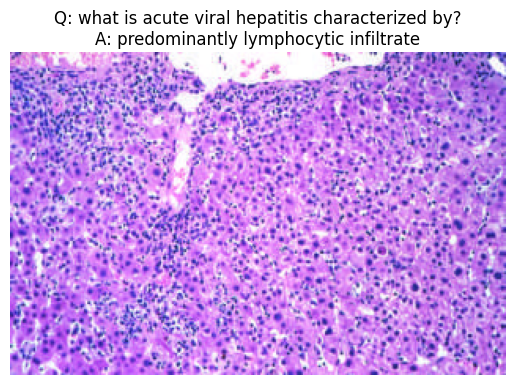

In [2]:
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
plt.axis('off')

pathvqa_valid = load_dataset("parquet", data_files={"validation": "hf://datasets/flaviagiammarino/path-vqa/data/validation-*.parquet"}, split="validation")
print('samplesize:', len(pathvqa_valid))
idx=3
print(pathvqa_valid[idx].keys())
print('image reso;ution:', np.array(pathvqa_valid[idx]['image']).shape)
plt.imshow(pathvqa_valid[idx]['image'])
plt.title(f'Q: {pathvqa_valid[idx]['question']}\nA: {pathvqa_valid[idx]['answer']}', fontsize=12)


#Prepare Dataloader

split: train = 2400 and test=600
Sample size: Training: 2400 validation: 600
image resolution: torch.Size([3, 224, 224])


Text(0.5, 1.0, 'Q: is gross islands of tumor?\nA: yes')

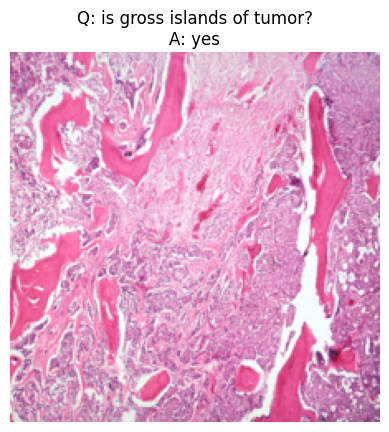

In [3]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader


class PathVQADataset(Dataset):
    def __init__(self, hf_dataset):
        """
        hf_dataset: HuggingFace dataset (already loaded split)
        """

        self.dataset = hf_dataset

        self.transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        # --- Image ---
        # HF dataset already provides PIL image
        raw_image = sample["image"].convert('RGB')
        img = self.transform(raw_image)

        # --- Question & Answer ---
        question = sample["question"]
        answer = sample["answer"]

        return img, question, answer

subset = pathvqa_valid.shuffle(seed=42).select(range(3000))
split_dataset = subset.train_test_split(test_size=0.2, seed=42)

# split_dataset = pathvqa_valid.train_test_split(test_size=0.2, seed=42)

train_data = split_dataset["train"]
val_data   = split_dataset["test"]
print(f'split: train = {len(train_data)} and test={len(val_data)}')

train_dataset = PathVQADataset(train_data)
val_dataset   = PathVQADataset(val_data)
print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)


img, question, answer = train_dataset[1]
print('image resolution:', img.size())
plt.axis('OFF')
plt.imshow(img.permute(1,2,0))
plt.title(f'Q: {question}\nA: {answer}', fontsize=12)

#Model Architecture

Paper: https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

GPT-2 uses a decoder-only transformer architecture with multiple model sizes; the commonly used GPT-2 Base model contains 12 transformer blocks (layers), a context window of 1024 tokens, a hidden embedding size of 768, and about 117 million parameters, while larger variants scale up to 48 transformer blocks and 1.5 billion parameters.

[1] Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. OpenAI blog, 1(8), 9.

###Cross-Attention Fusion

In [4]:
import math
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

####Cross-Attention Fusion###########
class CrossAttentionFusion(nn.Module):
    def __init__(self, hidden_dim=768, num_heads=8, dropout=0.1):
        super().__init__()

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.Dropout(dropout)
        )

    def forward(self, text_embeds, image_embeds, text_att_mask=None):
        """
        text_embeds:  [B, T, 768]
        image_embeds: [B, N, 768]
        text attends to image
        """

        attended_text, attn_weights = self.cross_attn(
            query=text_embeds,
            key=image_embeds,
            value=image_embeds,
            need_weights=False
        )

        x = self.norm1(text_embeds + attended_text)
        x = self.norm2(x + self.ffn(x))

        return x

W0604 15:53:18.950000 11895 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0604 15:53:19.062000 11895 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


###Gated Cross-Attention Fusion

In [ ]:
#Write your code for Gated-Cross Attention Fusion

###MedVQA model (Mulitmodal GPT2)

In [13]:
import math
import argparse
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


class MedVQA(nn.Module):
    def __init__(self, peft_config=None):
        super(MedVQA, self).__init__()

        # visual encoder
        model_name = "google/vit-base-patch16-224-in21k"
        self.visual_encoder = ViTModel.from_pretrained(model_name)

        # Freeze all parameters in visual encoder
        for param in self.visual_encoder.parameters():
            param.requires_grad = False

        # tokenizer
        self.tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
        self.tokenizer.pad_token = self.tokenizer.eos_token  # end of string

        # gpt2 decoder
        gpt = GPT2LMHeadModel.from_pretrained('gpt2')
        self.gpt = get_peft_model(gpt, peft_config)
        # self.gpt.print_trainable_parameters()  # Verify trainable LoRA parameters
        self.fusion = CrossAttentionFusion(
            hidden_dim=768,
            num_heads=4
        )

    def forward(self, image, qa_inputs_ids, qa_att_mask):
        image_embeds = self.visual_encoder(image).last_hidden_state
        # [B, 197, 768]

        text_embeds = self.gpt.get_input_embeddings()(qa_inputs_ids)
        # [B, T, 768]

        fused_embeds = self.fusion(
            text_embeds=text_embeds,
            image_embeds=image_embeds,
            text_att_mask=qa_att_mask
        )
        # [B, T, 768]

        gpt_output = self.gpt(
            inputs_embeds=fused_embeds,
            attention_mask=qa_att_mask
        )
        return gpt_output.logits


def get_arg():
    parser = argparse.ArgumentParser(description='VisualQuestionAnswerGeneration')
    # Training parameters
    parser.add_argument('--epochs',         type=int,   default=3,   help='number of epochs to train for')
    parser.add_argument('--batch_size',     type=int,   default=24,   help='batch size')
    parser.add_argument('--workers',        type=int,   default=8,    help='for data-loading')
    parser.add_argument('--random_seed',    type=int,   default=42,   help='random seed')
    parser.add_argument('--seq_length',     type=int,   default=68,   help='sequence length for question and answer')
    parser.add_argument('--dropout', type=float, default=0.1, help='dropout')

    parser.add_argument('--dataset',        default='endo',  help='endo / pit')
    parser.add_argument('--lr',             type=float, default=0.0002,  help='0.0000001, 0.00000005')
    parser.add_argument('--checkpoint_dir', default='checkpoints/',  help='path to checkpoint')

    args = parser.parse_args([])
    return args

#Model Training

In [7]:
#Training Script for Multimodal GPT2 with LoRA
import os
import torch
import argparse
import torch.utils.data
import numpy as np
import random

from torch import nn
from torch.utils.data import DataLoader
from transformers import GPT2Tokenizer

import evaluate
from nltk.translate.bleu_score import corpus_bleu
from peft import  TaskType, LoraConfig

import warnings
warnings.filterwarnings('ignore')

def adjust_learning_rate(optimizer, shrink_factor):
    print("\nDECAYING learning rate.")
    for param_group in optimizer.param_groups:
        param_group['lr'] = param_group['lr'] * shrink_factor
    print("The new learning rate is %f\n" % (optimizer.param_groups[0]['lr'],))

def train(args, train_dataloader, model, criterion, optimizer, epoch, tokenizer, device):
    model.train()
    total_loss = []

    for i, (images, questions, answers) in enumerate(train_dataloader, 0):
        # prepare prompts
        qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
        qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

        # get labels
        labels = qa_prompt_inputs['input_ids'].clone()
        labels = labels.to(device)

        # for labels, mask question tokens and padding tokens
        for idx, q in enumerate(questions):
            q_prompt = f"Question: {q}\nAnswer: "
            q_length = len(tokenizer(q_prompt)["input_ids"]) - 1

            labels[idx, :q_length] = -100  # mask question
            eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
            if eos_mask.sum() > 1:  # if more than 1 EOS
                first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS

        # get logits and labels
        logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
        )

        # get shifted logits and labels
        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        # compute loss
        shift_logits = shift_logits.view(-1, shift_logits.size(-1))
        shift_labels = shift_labels.view(-1)
        loss = criterion(shift_logits, shift_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss.append(loss.item())
        if i%50 == 0:
            print("Training - Epoch: {}/{}, Iteration: {}/{}, Training Loss: {:.6f}".format(epoch, args.epochs, i, len(train_dataloader), np.array(total_loss).mean()))


def validate(args, val_loader, model, criterion, epoch, tokenizer, device):
    total_loss = []
    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(val_loader, 0):
            # prepare prompts
            qa_prompt = [f'Question: {q}\nAnswer: {a}' for q, a in zip(questions, answers)]
            qa_prompt_inputs = tokenizer(qa_prompt, truncation=True, padding="max_length", max_length=int(args.seq_length), return_tensors="pt")

            # get labels
            labels = qa_prompt_inputs['input_ids'].clone()
            labels = labels.to(device)

            # for labels, mask question tokens and padding tokens
            answer_starts = []
            answer_ends = []
            for idx, q in enumerate(questions):
                q_prompt = f"Question: {q}\nAnswer: "
                q_length = len(tokenizer(q_prompt)["input_ids"]) - 1
                answer_starts.append(q_length+1)

                labels[idx, :q_length] = -100  # mask question
                eos_mask = (labels[idx] == tokenizer.eos_token_id)  # get all EOS position
                if eos_mask.sum() > 1:  # if more than 1 EOS
                    first_eos_pos = eos_mask.nonzero()[0].item()  # get first EOS position
                    labels[idx, (first_eos_pos+1):] = -100  # mask paddings, left one EOS
                    answer_ends.append(first_eos_pos)

            # get logits and labels
            logits = model(
                image=images.to(device),
                qa_inputs_ids=qa_prompt_inputs['input_ids'].to(device),
                qa_att_mask=qa_prompt_inputs['attention_mask'].to(device)
            )

            # get shifted logits and labels
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()

            # compute loss
            shift_logits = shift_logits.view(-1, shift_logits.size(-1))
            shift_labels = shift_labels.view(-1)
            loss = criterion(shift_logits, shift_labels)
            total_loss.append(loss.item())

    return np.array(total_loss).mean()


def seed_everything(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    np.random.seed(seed)
    random.seed(seed)


if __name__ == '__main__':

    args = get_arg()
    seed_everything(args.random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print(f'Batch size: {args.batch_size}')
    print(f'Learning rate: {args.lr}')
    print(f'Random seed: {args.random_seed}')
    print(f'Sequence length: {args.seq_length}')

    os.makedirs(args.checkpoint_dir, exist_ok = True)
    start_epoch = 1
    epochs_since_improvement = 0
    best_val_loss = float('inf')

    print(f'Dataset: {args.dataset}')
    train_dataloader = None
    val_dataloader = None


    train_dataset = PathVQADataset(train_data)
    val_dataset   = PathVQADataset(val_data)
    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

    print('Sample size: Training:', len(train_dataset), 'validation:', len(val_dataset))

    # init tokenizer and model
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    model = model.to(device)

    # for name, param in model.named_parameters():
    #     if param.requires_grad:
    #         print(name)

    pytorch_total_params = sum(p.numel() for p in model.parameters())
    print('model params: ', pytorch_total_params)

    # init optimizer and criterion
    optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
    criterion = nn.CrossEntropyLoss(ignore_index=-100).to(device)

    # train and validation
    print('Start training.')
    for epoch in range(start_epoch, args.epochs+1):
        if epochs_since_improvement > 0 and epochs_since_improvement % 5 == 0:
            adjust_learning_rate(optimizer, 0.8)

        # train
        train(args, train_dataloader=train_dataloader, model=model, criterion=criterion, optimizer=optimizer,
              epoch=epoch, tokenizer=tokenizer, device=device)
        # validation
        val_loss = validate(args, val_loader=val_dataloader, model=model, criterion=criterion,
                            epoch=epoch, tokenizer=tokenizer, device=device)

        if val_loss < best_val_loss:  # save model with better validation loss
            epochs_since_improvement = 0
            best_val_loss = val_loss
            save_dir = f'{args.checkpoint_dir}/best_model_ca.pth'
            torch.save(model.state_dict(), save_dir)
            model.tokenizer.save_pretrained(args.checkpoint_dir)
            print('Best validation loss, model saved.')
        else:
            epochs_since_improvement += 1
            print("\nEpochs since last improvement: %d\n" % (epochs_since_improvement,))
    print('End training.')

Batch size: 24
Learning rate: 0.0002
Random seed: 42
Sequence length: 68
Dataset: endo
Sample size: Training: 2400 validation: 600
Sample size: Training: 2400 validation: 600


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

model params:  218727936
Start training.
Training - Epoch: 1/3, Iteration: 0/75, Training Loss: 8.989951
Training - Epoch: 1/3, Iteration: 50/75, Training Loss: 5.218670
Best validation loss, model saved.
Training - Epoch: 2/3, Iteration: 0/75, Training Loss: 3.373161
Training - Epoch: 2/3, Iteration: 50/75, Training Loss: 3.274906
Best validation loss, model saved.
Training - Epoch: 3/3, Iteration: 0/75, Training Loss: 3.422080
Training - Epoch: 3/3, Iteration: 50/75, Training Loss: 2.707626
Best validation loss, model saved.
End training.


#Inference: few samples (prediction visualisations)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Sample size: valid: 600


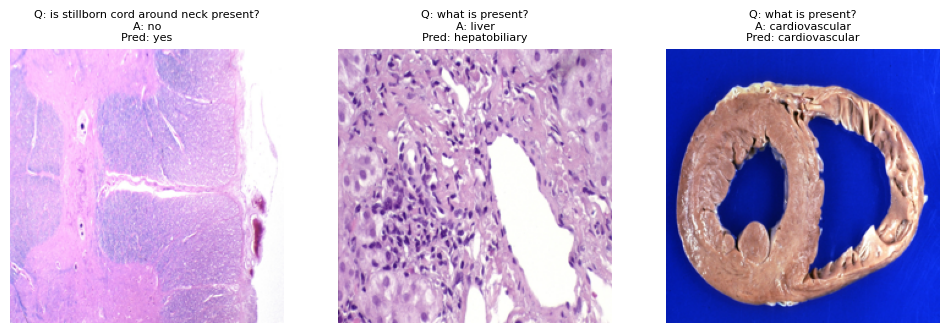

In [14]:
#run inference to collect the prediction visualisations
from tqdm import tqdm
import evaluate

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def greedy_search_single(image, question, model, tokenizer, max_length, device):
    model.eval()
    with torch.no_grad():
        # Prepare prompt and tokenize
        prompt_text = f"Question: {question}\nAnswer:"
        inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=False)
        input_ids = inputs['input_ids'].to(device)
        attention_mask = inputs['attention_mask'].to(device)

        # Pad to max_length
        padded_input_ids = torch.zeros((1, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((1, max_length), dtype=torch.long, device=device)
        seq_len = input_ids.size(1)
        padded_input_ids[:, :seq_len] = input_ids
        padded_attention_mask[:, :seq_len] = attention_mask

        valid_length = seq_len
        generated_ids = []

        image = image.unsqueeze(0).to(device)  # Add batch dim

        for _ in range(max_length - seq_len):
            logits = model(
                image=image,
                qa_inputs_ids=padded_input_ids[:, :valid_length],
                qa_att_mask=padded_attention_mask[:, :valid_length]
            )

            last_logits = logits[0, valid_length - 1]  # shape: [vocab_size]
            next_token_id = torch.argmax(F.softmax(last_logits, dim=-1), dim=-1)

            if next_token_id.item() == tokenizer.eos_token_id:
                break

            padded_input_ids[0, valid_length] = next_token_id
            padded_attention_mask[0, valid_length] = 1
            valid_length += 1
            generated_ids.append(next_token_id.item())

        # Decode generated tokens
        answer = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        return answer


def inference_few_samples(sample_indices = [4, 5, 7]):
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    save_dir = f'checkpoints/best_model_ca.pth'
    # save_dir = f'best_model_ca_lr1.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    print('Sample size: valid:', len(val_dataset))

    # Create subplots
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(12, 5))  # 1 row, 3 columns
    for ax, idx in zip(axes, sample_indices):
        img, question, answer_gt = val_dataset[idx]

        # Run inference
        pred_answer = greedy_search_single(img, question, model, tokenizer, max_length=34, device=device)
        img = img.permute(1, 2, 0)  # Convert from [C, H, W] to [H, W, C] for imshow
        ax.imshow(img)
        ax.set_title(f'Q: {question}\nA: {answer_gt}\nPred: {pred_answer}', fontsize=8)
        ax.axis('off')

args = get_arg()
inference_few_samples(sample_indices = [2, 80, 7])


#Inference: (Evaluation Metrics)

In [15]:
#run inference to collect the evaluation metrics (BLEU, ROUGE-L, and METEOR)
import os
import numpy as np
import random

import torch
import torch.utils.data
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig

from PIL import Image
from tqdm import tqdm
import evaluate
rouge = evaluate.load("rouge")
import time
import math
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


def batch_greedy_search(images, questions, model, tokenizer, max_length, device):
    answers = []
    batch_size = len(questions)

    model.eval()
    with torch.no_grad():
        # Prepare the prompts for the entire batch
        prompt_texts = [f"Question: {q}\nAnswer:" for q in questions]

        # Tokenize the prompts with padding to handle varying lengths
        prompt_inputs = tokenizer(
            prompt_texts,
            return_tensors="pt",
            padding='longest',
            add_special_tokens=False
        )

        # Prepare model inputs
        padded_input_ids = torch.zeros((batch_size, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((batch_size, max_length), device=device)

        orig_length = prompt_inputs['input_ids'].size(1)
        padded_input_ids[:, :orig_length] = prompt_inputs['input_ids'].to(device)
        padded_attention_mask[:, :orig_length] = prompt_inputs['attention_mask'].to(device)

        images = images.to(device)

        # Initialize tensors to store generated tokens
        only_answer_ids = torch.empty((batch_size, 0), dtype=torch.long, device=device)

        # Track which sequences have finished generating
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        # Record each sample length (number of non-eos tokens)
        valid_lengths = padded_attention_mask.sum(dim=1).long()
        batch_indices = torch.arange(batch_size, device=device)

        for _ in range(max_length - orig_length):
            max_valid_lengths = valid_lengths.max().item()

            logits = model(
                image=images,
                qa_inputs_ids=padded_input_ids[:, :max_valid_lengths],
                qa_att_mask=padded_attention_mask[:, :max_valid_lengths]
            )

            last_valid_logits = logits[batch_indices, valid_lengths - 1, :]
            next_token_ids = torch.argmax(last_valid_logits, dim=-1)

            is_eos = next_token_ids == tokenizer.eos_token_id
            finished = finished | is_eos

            padded_input_ids[batch_indices, valid_lengths] = next_token_ids
            padded_attention_mask[batch_indices, valid_lengths] = 1
            valid_lengths += 1

            only_answer_ids = torch.cat(
                [only_answer_ids, next_token_ids.unsqueeze(1)],
                dim=1
            )

            if finished.all():
                break

        # Decode the generated tokens into strings
        generated_ids_cpu = only_answer_ids.cpu().tolist()  # Move to CPU and convert to list for processing
        for i in range(batch_size):
            # Find the first occurrence of eos_token_id to truncate the answer
            try:
                eos_index = generated_ids_cpu[i].index(tokenizer.eos_token_id)
                answer_ids = generated_ids_cpu[i][:eos_index]
            except ValueError:
                # If eos_token_id is not found, use all generated tokens
                answer_ids = generated_ids_cpu[i]

            # Decode the token IDs to a string, skipping special tokens
            answer = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
            answers.append(answer)

    return answers

def validate(args, val_loader, model, tokenizer, device):
    references = []
    hypotheses = []

    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(tqdm(val_loader), 0):
            images = images.to(device)
            generated_answers = batch_greedy_search(
                images,
                questions,
                model,
                tokenizer,
                max_length=args.seq_length,
                device=device
            )

            references.extend(answers)
            hypotheses.extend(generated_answers)

    return references, hypotheses

def get_nlp_mettics(references, hypotheses):
    bleu = evaluate.load("bleu")
    rouge = evaluate.load("rouge")
    meteor = evaluate.load('meteor')

    # compute HF metrics
    results_bleu = bleu.compute(predictions=hypotheses, references=references)
    results_rouge = rouge.compute(predictions=hypotheses, references=references)
    results_meteor = meteor.compute(predictions=hypotheses, references=references)

    print("HuggingFace Metrics Results:")

    print(f"BLEU-1: {results_bleu['precisions'][0]:.6f}, "
      f"BLEU-2: {results_bleu['precisions'][1]:.6f}, ")

    # print(f"BLEU-4: {results_bleu['bleu']:.6f}")
    print(f"RougeL: {results_rouge['rougeL']:.6f}")
    print(f"Meteor: {results_meteor['meteor']:.6f}")


if __name__ == '__main__':
    # parameters
    random_seed = 42
    args = get_arg()
    # seed_everything(random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    val_dataloader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
    print('Sample size: valid:', len(val_dataset))

    # load weights
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    save_dir = f'checkpoints/best_model_ca.pth'
    # save_dir = f'best_model_ca_lr1.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    references, hypotheses = validate(args, val_loader=val_dataloader, model=model, tokenizer=tokenizer, device=device)
    get_nlp_mettics(references, hypotheses)


Sample size: valid: 600


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:06<00:00, 22.24s/it]


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


HuggingFace Metrics Results:
BLEU-1: 0.376997, BLEU-2: 0.000000, 
RougeL: 0.385542
Meteor: 0.192148


#Inference: (Evaluation Metrics + Entropy based Uncertainty)

In [16]:
#run inference to collect the evaluation metrics (BLEU, ROUGE-L, and METEOR)
import os
import numpy as np
import random

import torch
import torch.utils.data
from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision.transforms.functional import InterpolationMode
import torch.nn as nn
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import ViTModel, BlipTextModel
from peft import get_peft_model
from peft import  TaskType, LoraConfig

from PIL import Image
from tqdm import tqdm
import evaluate
rouge = evaluate.load("rouge")
import time
import math
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


def batch_greedy_search(images, questions, model, tokenizer, max_length, device):
    answers = []
    uncertainties = [[] for _ in range(len(questions))]  # Track uncertainty until EOS per sample
    batch_size = len(questions)

    model.eval()
    with torch.no_grad():
        # Prepare the prompts for the entire batch
        prompt_texts = [f"Question: {q}\nAnswer:" for q in questions]

        # Tokenize the prompts with padding to handle varying lengths
        prompt_inputs = tokenizer(
            prompt_texts,
            return_tensors="pt",
            padding='longest',
            add_special_tokens=False
        )

        # Prepare model inputs
        padded_input_ids = torch.zeros((batch_size, max_length), dtype=torch.long, device=device)
        padded_attention_mask = torch.zeros((batch_size, max_length), device=device)

        orig_length = prompt_inputs['input_ids'].size(1)
        padded_input_ids[:, :orig_length] = prompt_inputs['input_ids'].to(device)
        padded_attention_mask[:, :orig_length] = prompt_inputs['attention_mask'].to(device)

        images = images.to(device)

        # Initialize tensors to store generated tokens
        only_answer_ids = torch.empty((batch_size, 0), dtype=torch.long, device=device)

        # Track which sequences have finished generating
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)

        # Record each sample length (number of non-eos tokens)
        valid_lengths = padded_attention_mask.sum(dim=1).long()
        batch_indices = torch.arange(batch_size, device=device)

        for _ in range(max_length - orig_length):
            max_valid_lengths = valid_lengths.max().item()

            logits = model(
                image=images,
                qa_inputs_ids=padded_input_ids[:, :max_valid_lengths],
                qa_att_mask=padded_attention_mask[:, :max_valid_lengths]
            )

            last_valid_logits = logits[batch_indices, valid_lengths - 1, :]
            probs = F.softmax(last_valid_logits, dim=-1)
            # Compute entropy-based uncertainty
            entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)  # Add small value to avoid log(0)

            next_token_ids = torch.argmax(last_valid_logits, dim=-1)

            # Track uncertainty until EOS token for each sample
            for i in range(batch_size):
                if not finished[i]:  # Only store uncertainty for unfinished samples
                    uncertainties[i].append(entropy[i].item())

            is_eos = next_token_ids == tokenizer.eos_token_id
            finished = finished | is_eos

            padded_input_ids[batch_indices, valid_lengths] = next_token_ids
            padded_attention_mask[batch_indices, valid_lengths] = 1
            valid_lengths += 1

            only_answer_ids = torch.cat(
                [only_answer_ids, next_token_ids.unsqueeze(1)],
                dim=1
            )

            if finished.all():
                break

        # Decode the generated tokens into strings
        generated_ids_cpu = only_answer_ids.cpu().tolist()  # Move to CPU and convert to list for processing
        for i in range(batch_size):
            # Find the first occurrence of eos_token_id to truncate the answer
            try:
                eos_index = generated_ids_cpu[i].index(tokenizer.eos_token_id)
                answer_ids = generated_ids_cpu[i][:eos_index]
            except ValueError:
                # If eos_token_id is not found, use all generated tokens
                answer_ids = generated_ids_cpu[i]

            # Decode the token IDs to a string, skipping special tokens
            answer = tokenizer.decode(answer_ids, skip_special_tokens=True).strip()
            answers.append(answer)

    # Compute per-sample uncertainty by averaging entropies over all generated tokens for that sample
    samplewise_unc = [sum(unc) / len(unc) if len(unc) > 0 else 0.0 for unc in uncertainties]

    return answers, samplewise_unc

def validate(args, val_loader, model, tokenizer, device):
    references = []
    hypotheses = []
    samplewise_unc_all = []

    model.eval()
    with torch.no_grad():
        for i, (images, questions, answers) in enumerate(tqdm(val_loader), 0):
            images = images.to(device)
            generated_answers, samplewise_unc = batch_greedy_search(
                images,
                questions,
                model,
                tokenizer,
                max_length=args.seq_length,
                device=device
            )

            references.extend(answers)
            hypotheses.extend(generated_answers)
            samplewise_unc_all.extend(samplewise_unc)

    return references, hypotheses, samplewise_unc_all

def get_nlp_mettics(references, hypotheses):
    bleu = evaluate.load("bleu")
    rouge = evaluate.load("rouge")
    meteor = evaluate.load('meteor')

    # compute HF metrics
    results_bleu = bleu.compute(predictions=hypotheses, references=references)
    results_rouge = rouge.compute(predictions=hypotheses, references=references)
    results_meteor = meteor.compute(predictions=hypotheses, references=references)

    print("HuggingFace Metrics Results:")

    print(f"BLEU-1: {results_bleu['precisions'][0]:.6f}, "
      f"BLEU-2: {results_bleu['precisions'][1]:.6f}, ")
    print(f"RougeL: {results_rouge['rougeL']:.6f}")
    print(f"Meteor: {results_meteor['meteor']:.6f}")
    samplewise_rouge = rouge.compute(predictions=hypotheses, references=references, use_aggregator=False)

    return samplewise_rouge['rougeL']


if __name__ == '__main__':
    # parameters
    random_seed = 42
    args = get_arg()
    # seed_everything(random_seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    val_dataset   = PathVQADataset(val_data)
    val_dataloader   = DataLoader(val_dataset, batch_size=256, shuffle=False)
    print('Sample size: valid:', len(val_dataset))

    # load weights
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["c_attn", "c_proj"]
    )

    model = MedVQA(peft_config=lora_config)
    save_dir = f'checkpoints/best_model_ca.pth'
    # save_dir = f'best_model_ca_lr1.pth'
    model.load_state_dict(torch.load(save_dir, map_location=device))
    model.to(device)
    model.eval()

    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token

    references, hypotheses, samplewise_unc_all = validate(args, val_loader=val_dataloader, model=model, tokenizer=tokenizer, device=device)

    samplewise_rougeL = get_nlp_mettics(references, hypotheses)
    print(len(samplewise_unc_all), len(samplewise_rougeL))


Sample size: valid: 600


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

100%|██████████| 3/3 [01:06<00:00, 22.08s/it]
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


HuggingFace Metrics Results:
BLEU-1: 0.376997, BLEU-2: 0.000000, 
RougeL: 0.385542
Meteor: 0.192148
600 600


Average RougeL after removing samples with highest uncertainty:
After removing top 0%: 0.3854
After removing top 20%: 0.4660
After removing top 40%: 0.5546
After removing top 60%: 0.6292
After removing top 80%: 0.6333


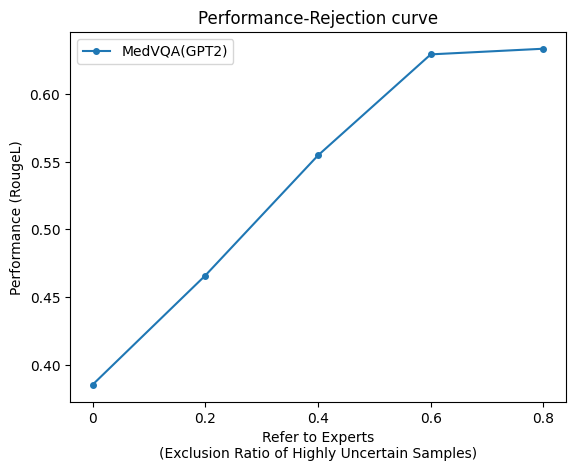

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure numpy arrays for easier manipulation
uncertainty_array = np.array(samplewise_unc_all)
rougeL_array = np.array(samplewise_rougeL)

# Get sorted indices based on uncertainty in descending order (highest uncertainty first)
sorted_indices = np.argsort(-uncertainty_array)

# Sort RougeL scores based on sorted uncertainty indices
sorted_rougeL = rougeL_array[sorted_indices]

# Define removal percentages
removal_percentages = [0, 20, 40, 60, 80]

print("Average RougeL after removing samples with highest uncertainty:")
avg_rougeL_by_refer = []
for percent in removal_percentages:
    num_to_remove = int(len(sorted_rougeL) * (percent / 100))
    remaining_rougeL = sorted_rougeL[num_to_remove:]  # Remove top N% uncertain samples
    avg_rougeL = np.mean(remaining_rougeL) if len(remaining_rougeL) > 0 else 0
    print(f"After removing top {percent}%: {avg_rougeL:.4f}")
    avg_rougeL_by_refer.append(avg_rougeL)

refer = np.array(['0' , 0.2 , 0.4 ,  0.6 ,  0.8  ])
avg_rougeL_by_refer = np.array(avg_rougeL_by_refer)

ax = plt.gca()
lineObjects = ax.plot(refer, avg_rougeL_by_refer.transpose(),marker='o',markersize=4)
legends = ['MedVQA(GPT2)']
ax.legend(lineObjects, legends)
ax.set_ylabel('Performance (RougeL)')
ax.set_xlabel("Refer to Experts\n(Exclusion Ratio of Highly Uncertain Samples)")
ax.set_title('Performance-Rejection curve');
plt.savefig("Performance_rejection_curve.pdf", bbox_inches='tight', dpi=1500)
